# Forgetting: Why, and Which Kind

A conjugate linear model never forgets. Every observation adds to the
posterior precision, the posterior standard deviation of each coefficient
shrinks like $1/\sqrt{n}$, and after ten thousand rewards the model is as
good as certain. If the world then changes, it takes roughly another ten
thousand rewards to change its mind. Forgetting keeps the posterior from
freezing.

This notebook is about *how* to forget. The simplest rule, scaling the
whole precision matrix by $\gamma$ each step, is what `learning_rate < 1`
and `agent.decay()` do today. It has a classic failure mode, *covariance
windup*, that is easy to hit in bandits, where some arms are pulled far
more often than others. Two
*directional* rules forget only what was observed, and they differ in ways
that matter for both hierarchical and sparse models. The
[math reference](../math/forgetting.rst) has the equations; here we look at
pictures.

We work directly with the posterior precision $\Lambda$ (inverse
covariance) and mean $\theta$, because that is where forgetting acts. One
round of the loop is: forget, then update. Forgetting changes $\Lambda$ and
leaves $\theta$ where it is.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.linalg import cho_factor, cho_solve

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ALPHA = 1.0  # prior precision
BETA = 4.0  # noise precision (noise sd 0.5)


def update(R_bar, theta, x, y):
    # Bayesian linear regression update from the forgotten precision R_bar.
    R_new = R_bar + BETA * np.outer(x, x)
    theta_new = cho_solve(cho_factor(R_new), R_bar @ theta + BETA * x * y)
    return R_new, theta_new


def covariance(R):
    return cho_solve(cho_factor(R), np.eye(len(R)))

The four forgetting rules, written out for a dense precision matrix and a
single observation row $x$. Each takes the precision before the update and
returns the precision after forgetting.

| Rule | Formula | What it does to the posterior |
|---|---|---|
| Exponential | $\bar\Lambda = \gamma\Lambda$ | Stretches the uncertainty ellipse uniformly |
| Stabilized | $\bar\Lambda = \gamma\Lambda + (1-\gamma)\alpha I$ | Same stretch, but never past the prior |
| Feature-wise | $\bar\Lambda = D\Lambda D$, $D = \mathrm{diag}(\gamma^{m_i/2})$ | Stretches only the observed coordinates |
| SIFt | $\bar\Lambda = \Lambda - (1-\gamma)\dfrac{\Lambda x x^\top \Lambda}{x^\top\Lambda x}$ | Blurs the posterior along the observed direction |

$m_i$ is the number of rows in which feature $i$ is nonzero, so for one
row it is 1 on the observed features and 0 elsewhere.

In [2]:
def exponential(R, x, gamma):
    return gamma * R


def stabilized(R, x, gamma):
    return gamma * R + (1 - gamma) * ALPHA * np.eye(len(x))


def feature_wise(R, x, gamma):
    d = np.where(x != 0, np.sqrt(gamma), 1.0)
    return d[:, None] * R * d[None, :]


def sift(R, x, gamma):
    w = R @ x
    return R - (1 - gamma) * np.outer(w, w) / (x @ w)


RULES = {
    "exponential": exponential,
    "stabilized": stabilized,
    "feature-wise": feature_wise,
    "SIFt": sift,
}

## Why forget at all?

One arm, one coefficient (its mean reward). The true mean drops from 1.0
to 0.0 halfway through. With no forgetting the posterior has already
collapsed to a needle by then, and the mean crawls toward the new value at
a rate set by how many old observations it has to outvote. With
exponential forgetting at $\gamma = 0.98$, the posterior width settles at a
floor and the mean tracks the change within a few dozen observations.

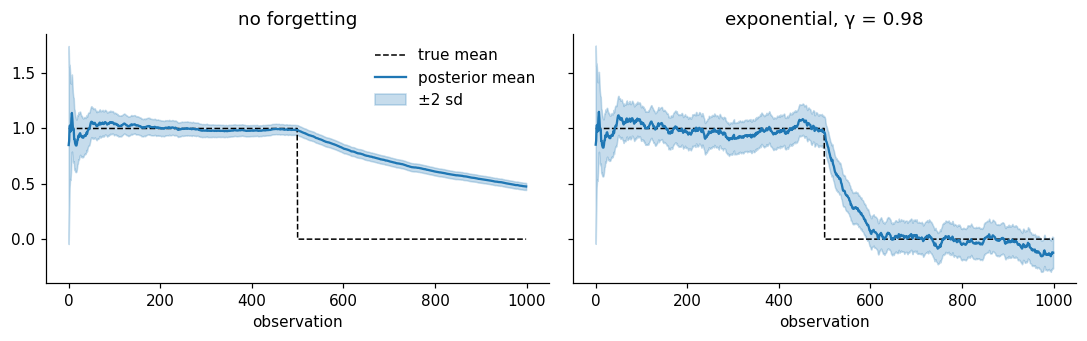

In [3]:
rng = np.random.default_rng(0)
T, SHIFT = 1000, 500
truth = np.where(np.arange(T) < SHIFT, 1.0, 0.0)
rewards = truth + rng.normal(0, 0.5, T)
x1 = np.array([1.0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, gamma in zip(axes, [1.0, 0.98]):
    R, theta = ALPHA * np.eye(1), np.zeros(1)
    means, sds = [], []
    for t in range(T):
        R, theta = update(exponential(R, x1, gamma), theta, x1, rewards[t])
        means.append(theta[0])
        sds.append(np.sqrt(covariance(R)[0, 0]))
    means, sds = np.array(means), np.array(sds)
    ax.plot(truth, color="k", lw=1, ls="--", label="true mean")
    ax.plot(means, color="C0", label="posterior mean")
    ax.fill_between(
        np.arange(T),
        means - 2 * sds,
        means + 2 * sds,
        color="C0",
        alpha=0.25,
        label="±2 sd",
    )
    ax.set_title("no forgetting" if gamma == 1.0 else f"exponential, γ = {gamma}")
    ax.set_xlabel("observation")
axes[0].legend(loc="upper right", frameon=False)
plt.tight_layout()

## Covariance windup

Exponential forgetting takes a fraction $1 - \gamma$ of the precision
out of every direction at every step. An observation puts precision
back, but only along its own row. In a direction that observations keep
exciting, the two balance and the posterior width settles at a floor,
which is what happened in the plot above. In a direction that the data
rarely or never excites, nothing balances the removal. The precision
there decays like $\gamma^t$, the variance grows like $\gamma^{-t}$,
and the posterior widens without limit. In the recursive least squares
literature this is called covariance windup, and a bandit that has
settled on a favourite arm is a natural place for it to happen.

To see it, use the model a bandit with a shared learner actually fits,
which is a one-way ANOVA. There is a grand mean $\mu$ (the intercept
column) and one treatment effect $\tau_a$ per arm (the one-hot columns),
and an observation from arm $a$ has expected reward $\mu + \tau_a$. A
policy that has settled on arm 0 pulls it 90% of the time, and arms 1
and 2 get 5% each.

Anyone who has fit an ANOVA knows that the data only determine the cell
means $\mu + \tau_a$. The split into a grand mean and effects is a
convention: add a constant to $\mu$ and subtract it from every
$\tau_a$, and every cell mean is unchanged. Classical ANOVA settles the
split with a side constraint such as $\sum_a \tau_a = 0$. A ridge model
settles it with the prior, which prefers the split with the smallest
coefficients. That is all that ever pins the split, and it is where
windup strikes.

Two directions wind up in this model.

1. **The rarely pulled arms.** The cell mean $\mu + \tau_1$ gets
   precision only when arm 1 is pulled, one observation in twenty. In
   between, it loses $1 - \gamma$ of its precision on each of arm 0's
   observations, which carry no information about it.
2. **The split.** Adding $c$ to $\mu$ and subtracting $c$ from every
   $\tau_a$ changes no cell mean, so no observation ever adds precision
   in that direction. Only the prior did. Its contribution decays as
   $\alpha\gamma^t$, and the variance of the split grows until the
   Cholesky factorization fails. Every prediction was correct right up
   to the failure, because predictions are cell means and the split does
   not enter them.

The directional rules are meant to stop windup by forgetting only in
directions the current observation excites. We run the same sequence of
pulls under all four rules with the same $\gamma$, and track the
posterior standard deviation of each cell mean and the posterior
variance of the split, measured along $(1, -1, -1, -1)/2$.

In [4]:
rng = np.random.default_rng(1)
T, GAMMA = 2000, 0.98
P_PULL = np.array([0.9, 0.05, 0.05])
ARM_MEANS = np.array([1.0, 0.5, 0.0])
arms = rng.choice(3, size=T, p=P_PULL)
rewards = ARM_MEANS[arms] + rng.normal(0, 0.5, T)


def row(arm):
    x = np.zeros(4)
    x[0] = 1.0
    x[1 + arm] = 1.0
    return x


SPLIT_DIR = np.array([1.0, -1.0, -1.0, -1.0]) / 2  # mu up, every tau down


def run(rule, gamma=GAMMA):
    R, theta = ALPHA * np.eye(4), np.zeros(4)
    pred_sd = np.full((T, 3), np.nan)
    split_var = np.full(T, np.nan)
    for t in range(T):
        x = row(arms[t])
        try:
            R, theta = update(rule(R, x, gamma), theta, x, rewards[t])
        except np.linalg.LinAlgError:
            print(f"{rule.__name__}: Cholesky failed at observation {t}")
            break
        S = covariance(R)
        pred_sd[t] = [np.sqrt(row(a) @ S @ row(a)) for a in range(3)]
        split_var[t] = SPLIT_DIR @ S @ SPLIT_DIR
    return pred_sd, split_var


results = {name: run(rule) for name, rule in RULES.items()}

exponential: Cholesky failed at observation 1575


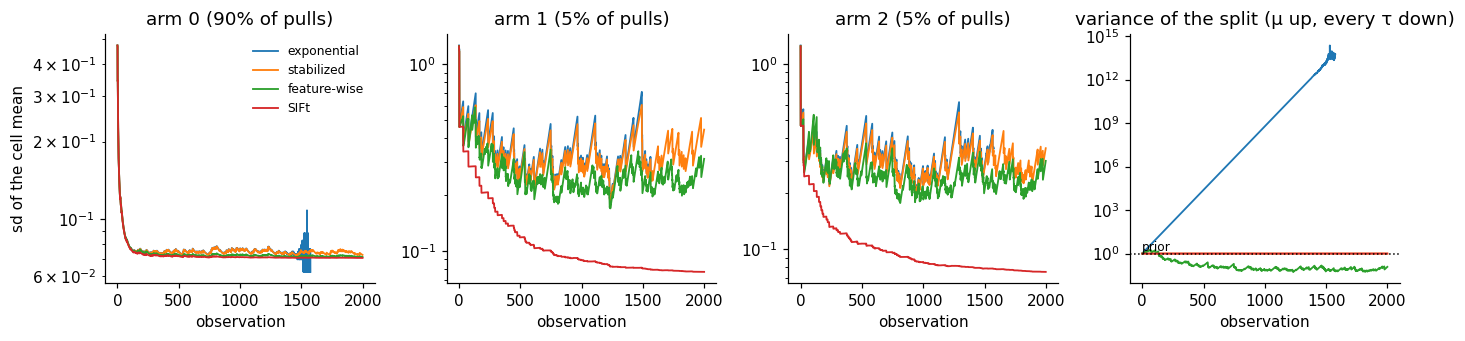

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for a in range(3):
    ax = axes[a]
    for name, (pred_sd, _) in results.items():
        ax.plot(pred_sd[:, a], label=name, lw=1.2)
    ax.set_title(f"arm {a} ({int(P_PULL[a] * 100)}% of pulls)")
    ax.set_ylabel("sd of the cell mean" if a == 0 else "")
    ax.set_xlabel("observation")
    ax.set_yscale("log")
ax = axes[3]
for name, (_, split_var) in results.items():
    ax.plot(split_var, label=name, lw=1.2)
ax.axhline(1 / ALPHA, color="k", ls=":", lw=1)
ax.text(0, 1.4 / ALPHA, "prior", fontsize=8)
ax.set_yscale("log")
ax.set_title("variance of the split (μ up, every τ down)")
ax.set_xlabel("observation")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()

In [6]:
print(f"{'rule':13s} {'cell-mean sd, arms 0/1/2':>26s} {'variance of the split':>24s}")
for name, (pred_sd, split_var) in results.items():
    last = np.flatnonzero(~np.isnan(split_var))[-1]
    print(
        f"{name:13s} {str(np.round(pred_sd[last], 3)):>26s} {split_var[last]:>24.2g}   (at observation {last})"
    )

rule            cell-mean sd, arms 0/1/2    variance of the split
exponential          [0.062 0.265 0.354]                  5.4e+13   (at observation 1574)
stabilized           [0.073 0.446 0.351]                        1   (at observation 1999)
feature-wise         [0.071 0.311 0.3  ]                     0.12   (at observation 1999)
SIFt                 [0.071 0.077 0.075]                        1   (at observation 1999)


Exponential forgetting winds up in both directions. The rare arms' cell
means widen on arm 0's pulls, and the variance of the split grows by
fourteen orders of magnitude until the factorization fails.

Stabilized forgetting puts a floor under the windup at the prior. The
rare arms are still forgotten on arm 0's pulls, but never beyond the
variance $1/\alpha$ the prior started them with. This is the rule the
empirical Bayes estimators use.

SIFt shows no windup. The rare arms keep the precision their own pulls
earned, and the split stays exactly where the prior put it.

Feature-wise shows no windup either, but two things are off. The rare
arms' cell means are several times wider than under SIFt, even though
nothing new was observed about them. And the split, which no
observation informs, ends up far tighter than the prior. The two facts
have the same explanation, and it is easiest to see in ANOVA terms.

### Where the precision of the split came from

Take one observation from arm 1. The model records it as information
about $\mu + \tau_1$: the cell mean was about 0.5. It says nothing
about $\mu$ alone or $\tau_1$ alone, and in particular nothing about
the split, because moving $c$ from $\tau_1$ into $\mu$ leaves
$\mu + \tau_1$ alone.

Now arm 0 is pulled, and feature-wise forgets a fraction of what the
model knows about $\mu$ and about $\tau_0$. But the model knows
nothing about $\mu$ on its own. All it has is cell means, each with
$\mu$ inside it. So "forget some of $\mu$" means going into every
cell's record, arm 1's included, and shrinking the $\mu$ part of it.
After $k$ arm-0 pulls, arm 1's record no longer reads
"$\mu + \tau_1 \approx 0.5$" but
"$\gamma^{k/2}\mu + \tau_1 \approx 0.5$". That is a treatment effect
that has been cut loose from its baseline.

Once the record reads that way, moving $c$ from $\tau_1$ into $\mu$
does change it, by $c\,(1 - \gamma^{k/2})$. The record now resists the
move, which is to say it carries precision along the split. And it
constrains the cell mean $\mu + \tau_1$ less than it did, because part
of its weight now points at the wrong combination. The cell below does
the arithmetic for one record: its precision along the cell mean and
along the split after 0, 10, 50 and 200 arm-0 pulls.

In [7]:
piece = BETA * np.outer(row(1), row(1))  # what one arm-1 observation adds to Λ
CELL_DIR = row(1) / np.sqrt(2)  # the cell mean mu + tau_1
D_arm0 = np.diag(np.where(row(0) != 0, np.sqrt(GAMMA), 1.0))  # one arm-0 pull

print(
    f"{'arm-0 pulls since':>18s} {'precision on the cell mean':>27s} {'precision on the split':>24s}"
)
for k in [0, 10, 50, 200]:
    Dk = np.linalg.matrix_power(D_arm0, k)
    forgotten = Dk @ piece @ Dk
    print(
        f"{k:>18d} {CELL_DIR @ forgotten @ CELL_DIR:>27.3f} {SPLIT_DIR @ forgotten @ SPLIT_DIR:>24.3f}"
    )

 arm-0 pulls since  precision on the cell mean   precision on the split
                 0                       8.000                    0.000
                10                       7.250                    0.009
                50                       5.142                    0.157
               200                       2.566                    0.752


Some of what the cell mean loses is genuinely forgotten, and the rest
turns into precision along the split. Over the run there are about two
hundred rare-arm observations, and this happens to every one of them,
which is how the split ends up with nearly a hundred times the
precision the prior gave it. In ANOVA language, feature-wise forgetting
has slowly imposed a side constraint of its own: one that holds the
treatment effects at their old values in absolute terms and puts all of
the change onto the grand mean. Nothing in the data asked for that
constraint, and it is why the rare arms' cell means are wider than they
should be.

SIFt cannot do this, because it never forgets a coordinate. On an arm-0
pull it forgets along the direction that arm 0's row excites, which is
the cell mean $\mu + \tau_0$, and it forgets by adding noise whose size
is set by how well that cell mean is currently known. Arm 0 has been
pulled eighteen hundred times, so the noise is tiny and the other cells
barely feel it.

None of this is a quirk of the small model. It appears whenever a
column is shared between rows that are observed at very different
rates, which is the definition of a hierarchical design: a grand mean
shared by every arm, or an arm effect shared by every segment within
the arm. Remove the shared column and it disappears. With one-hot
columns alone each cell has its own coordinate, the posterior is
diagonal, and the two directional rules give identical results.

The exponential and stabilized curves for the rare arms are not simply
wrong, either. Arm 1's uncertainty growing while it is not being pulled
is what makes a Thompson sampling policy go back and check on it. If
rewards drift with wall-clock time whether or not you observe them, that
is the behaviour you want. The safe way to get it is to keep
`learning_rate = 1.0` and call `decay()` on a schedule, as the
[decay guide](../howto/decay.rst) recommends, rather than to let
per-observation decay run until the split winds up.

## Stretch or blur: what the two directional rules do to a posterior

A picture of the mechanism. Two coefficients with posterior correlation
$\rho = 0.8$, and we forget one observation of feature 0 alone,
$x = (1, 0)$, at $\gamma = 0.7$. A large step so the shapes are visible.

- **Exponential** stretches the ellipse uniformly. Every direction gets
  the same factor.
- **Feature-wise** stretches the $\theta_0$ axis only. It multiplies the
  variance of $\theta_0$ by $1/\gamma$, the covariance by
  $1/\sqrt{\gamma}$, and leaves $\theta_1$ alone. The correlation is
  unchanged, so the ellipse keeps its tilt.
- **SIFt** adds noise to $\theta_0$: $\bar\Sigma = \Sigma + q\,x x^\top$
  with $q = \frac{1-\gamma}{\gamma\, x^\top \Lambda x}$. It is the predict
  step of a Kalman filter whose process noise lives only on the observed
  direction. The covariance and $\theta_1$ are untouched, so the ellipse
  gets *wider along $\theta_0$ and less tilted*.

Stretching is multiplicative and keeps the shape of the ellipse.
Blurring is additive and changes it.

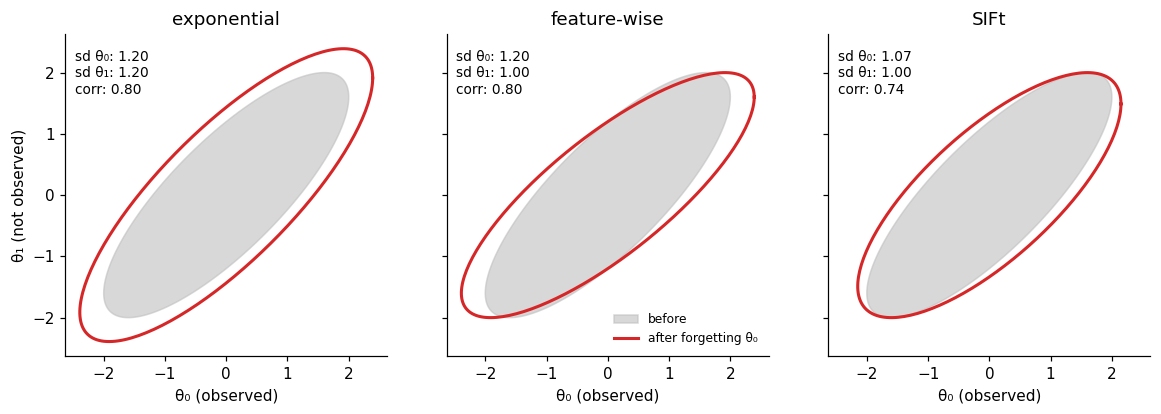

In [8]:
def ellipse(S, n=200):
    t = np.linspace(0, 2 * np.pi, n)
    pts = 2 * np.linalg.cholesky(S) @ np.stack([np.cos(t), np.sin(t)])
    return pts[0], pts[1]


RHO, GAMMA_2D = 0.8, 0.7
Sigma = np.array([[1.0, RHO], [RHO, 1.0]])
Lam = np.linalg.inv(Sigma)
x0 = np.array([1.0, 0.0])
GEOMETRY = ["exponential", "feature-wise", "SIFt"]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for ax, name in zip(axes, GEOMETRY):
    S_bar = np.linalg.inv(RULES[name](Lam, x0, GAMMA_2D))
    ax.fill(*ellipse(Sigma), color="0.75", alpha=0.6, label="before")
    ax.plot(*ellipse(S_bar), color="C3", lw=2, label="after forgetting θ₀")
    ax.set_title(name)
    ax.set_xlabel("θ₀ (observed)")
    ax.set_aspect("equal")
    corr = S_bar[0, 1] / np.sqrt(S_bar[0, 0] * S_bar[1, 1])
    ax.text(
        0.03,
        0.95,
        f"sd θ₀: {np.sqrt(S_bar[0, 0]):.2f}\nsd θ₁: {np.sqrt(S_bar[1, 1]):.2f}\ncorr: {corr:.2f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
    )
axes[0].set_ylabel("θ₁ (not observed)")
axes[1].legend(loc="lower right", frameon=False, fontsize=8)
plt.tight_layout()

### What each one gives up

Both directional rules leave the marginal of $\theta_1$ alone, and they
coincide exactly when $\theta_0$ and $\theta_1$ are uncorrelated in the
posterior. With correlation they make different promises.

**SIFt is a proper Bayesian step.** "The coefficient I observed may have
moved since; add noise to it." Every direction gets wider or stays the
same, never narrower. That is what the Kalman predict step guarantees,
and it is why SIFt can be applied for as long as you like without the
posterior drifting somewhere strange.

**Feature-wise is a tempering step.** "Discount everything I know about
$\theta_0$ by $\gamma$, but keep the shape of the joint." Keeping the
tilt has a cost: in a band of mixed directions the posterior gets
slightly *narrower*, which no forgetting step should do. It is the
same thing that tightened the split in the ANOVA example, seen for a
single step. The plot below shows the posterior
standard deviation in every direction of the plane, before and after
each rule. Feature-wise dips below the "before" curve; SIFt never does.

feature-wise, worst direction: sd ratio after/before = 0.943 at 114°


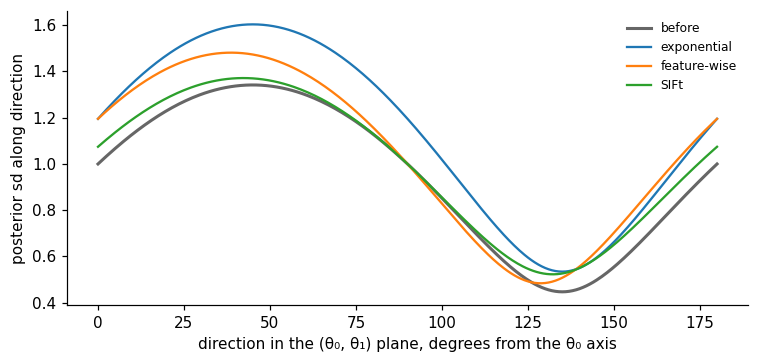

In [9]:
angles = np.linspace(0, np.pi, 361)
U = np.stack([np.cos(angles), np.sin(angles)])


def sd_by_direction(S):
    return np.sqrt(np.einsum("ij,ik,kj->j", U, S, U))


fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(np.degrees(angles), sd_by_direction(Sigma), color="0.4", lw=2, label="before")
for name in GEOMETRY:
    S_bar = np.linalg.inv(RULES[name](Lam, x0, GAMMA_2D))
    ax.plot(np.degrees(angles), sd_by_direction(S_bar), lw=1.5, label=name)
ax.set_xlabel("direction in the (θ₀, θ₁) plane, degrees from the θ₀ axis")
ax.set_ylabel("posterior sd along direction")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()

S_fw = np.linalg.inv(feature_wise(Lam, x0, GAMMA_2D))
ratio = sd_by_direction(S_fw) / sd_by_direction(Sigma)
print(
    f"feature-wise, worst direction: sd ratio after/before = {ratio.min():.3f} "
    f"at {np.degrees(angles[ratio.argmin()]):.0f}°"
)

How much this matters depends on how correlated the features are and how
hard you forget. At the $\gamma = 0.7$ used for the pictures the dip is
noticeable. At a realistic per-observation $\gamma$ it is small unless
features are strongly correlated:

In [10]:
print("worst-direction sd ratio for feature-wise, one observation of θ₀")
print(f"{'':>8s}" + "".join(f"ρ={r:<7}" for r in [0.5, 0.8, 0.95, 0.99]))
for g in [0.98, 0.9, 0.7]:
    line = f"γ={g:<5} "
    for r in [0.5, 0.8, 0.95, 0.99]:
        S = np.array([[1.0, r], [r, 1.0]])
        S_fw = np.linalg.inv(feature_wise(np.linalg.inv(S), x0, g))
        line += f"{(sd_by_direction(S_fw) / sd_by_direction(S)).min():<9.3f}"
    print(line)

worst-direction sd ratio for feature-wise, one observation of θ₀
        ρ=0.5    ρ=0.8    ρ=0.95   ρ=0.99   
γ=0.98  0.999    0.997    0.989    0.970    
γ=0.9   0.996    0.983    0.944    0.853    
γ=0.7   0.986    0.943    0.825    0.602    


On every count so far SIFt is the better-behaved rule. What it costs
is sparsity.

## The cost: SIFt fills in sparse models

For a sparse model, the precision matrix has a nonzero wherever two
features have appeared in the same row. With an intercept plus one-hot
columns for arms and arm-by-segment cells, that pattern is a star: the
intercept touches everything, each arm touches its cells, and the cells
touch nothing else. It stays sparse no matter how many observations
arrive, and the sparse Cholesky factor stays cheap.

Exponential, stabilized and feature-wise forgetting scale entries of
$\Lambda$ in place, so the pattern never changes. SIFt subtracts a
rank-one matrix $\Lambda x x^\top \Lambda$. The vector $\Lambda x$ is
nonzero on every feature that shares a row with the observed ones, and
with a shared intercept that is *every feature seen so far*. Each SIFt
step therefore writes a dense block over everything the model has ever
seen, and after a few hundred observations the precision matrix is
dense.

The rules in `bayesianbandits._forgetting` are the sparse-aware versions
used by the estimators. We run them on a model with one intercept, 50
arms, and 10 segments per arm, and count the nonzeros in $\Lambda$ after
each observation.

exponential   nnz after 400 observations:    1767  (0.6% dense)
feature-wise  nnz after 400 observations:    1767  (0.6% dense)
SIFt          nnz after 400 observations:  109121  (35.9% dense)


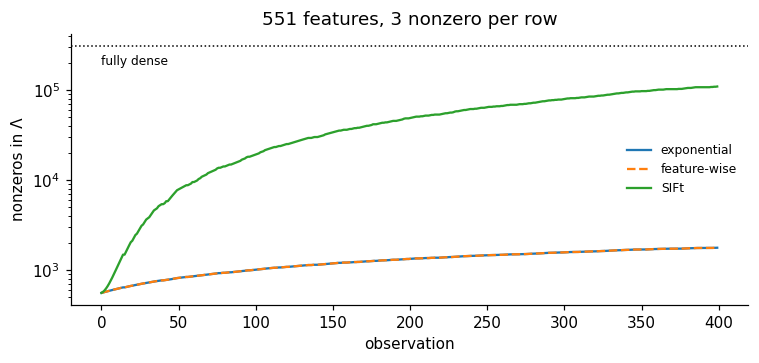

In [11]:
from bayesianbandits._forgetting import (
    ExponentialForgetting,
    FeatureWiseForgetting,
    SiftForgetting,
)

N_ARMS, N_SEG = 50, 10
P = 1 + N_ARMS + N_ARMS * N_SEG
rng = np.random.default_rng(2)


def sparse_row(arm, seg):
    cols = [0, 1 + arm, 1 + N_ARMS + arm * N_SEG + seg]
    return sparse.csc_array((np.ones(3), ([0, 0, 0], cols)), shape=(1, P))


T_SPARSE = 400
draws = [(rng.integers(N_ARMS), rng.integers(N_SEG)) for _ in range(T_SPARSE)]
sparse_rules = {
    "exponential": ExponentialForgetting(),
    "feature-wise": FeatureWiseForgetting(),
    "SIFt": SiftForgetting(eps=1e-10),
}
nnz = {}
for name, rule in sparse_rules.items():
    R = sparse.csc_array(ALPHA * sparse.eye(P))
    counts = []
    for arm, seg in draws:
        X = sparse_row(arm, seg)
        R_bar, _, _ = rule(R, X, np.zeros(1), GAMMA)
        R = sparse.csc_array(R_bar + BETA * (X.T @ X))
        R.eliminate_zeros()
        counts.append(R.nnz)
    nnz[name] = np.array(counts)

fig, ax = plt.subplots(figsize=(7, 3.4))
for name, counts in nnz.items():
    ax.plot(counts, label=name, lw=1.5, ls="--" if name == "feature-wise" else "-")
ax.axhline(P * P, color="k", ls=":", lw=1)
ax.text(0, P * P * 0.8, "fully dense", fontsize=8, va="top")
ax.set_yscale("log")
ax.set_xlabel("observation")
ax.set_ylabel("nonzeros in Λ")
ax.set_title(f"{P} features, 3 nonzero per row")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
for name, counts in nnz.items():
    print(
        f"{name:13s} nnz after {T_SPARSE} observations: {counts[-1]:>7d}  ({counts[-1] / P**2:.1%} dense)"
    )

The exponential and feature-wise curves lie on top of each other: the
pattern is whatever the data made it. SIFt's curve tracks the square of
the number of features seen so far, and at this size it is a third of
the way to dense within a few hundred observations. At a million
features, which is where the sparse estimators are meant to operate,
that is not a slowdown but a memory failure. This is why the library
treats SIFt as a dense-only rule and feature-wise as the directional
rule for sparse models.

## Choosing

| | Forgets | Sparsity | Watch out for |
|---|---|---|---|
| **Exponential** | everything, every step | preserved | prior collapse on unobserved directions; rare arms forgotten by common ones |
| **Stabilized** | everything, down to the prior floor | preserved | rare arms still forgotten by common ones; used by the empirical Bayes estimators |
| **Feature-wise** | the observed coordinates | preserved | no windup, but forgetting a shared column cuts the other cells' effects loose from their baseline: rare cells widen, the split tightens |
| **SIFt** | what the observed rows taught, as added noise | destroyed | dense fill-in; dense models only |

Three practical notes.

**The same $\gamma$ means different amounts of forgetting.** One
exponential step removes a fraction $1-\gamma$ of the precision in all
$p$ directions. A feature-wise step removes it in the $k$ observed
coordinates, and a SIFt step along one direction. If you switch rules and
want the same total rate of forgetting, expect to retune $\gamma$; a
rough conversion for a row with $k$ nonzeros is
$\gamma_{\text{sift}} \approx \gamma_{\text{fw}}^{\,k}$.

**Shared columns are where the directional rules part ways.** With
one-hot arm columns and no intercept the two coincide, and feature-wise
is exact. Add a grand mean or any other shared level, and feature-wise
widens the rare cells well beyond SIFt, though still without windup.

**Time-based or observation-based?** Directional rules forget an arm
only when it is observed. If rewards drift over time regardless, an arm
that is never pulled keeps a stale, confident posterior. Exponential
`decay()` on a schedule is the tool for that, and the two can be combined:
directional forgetting per update to keep the precision well conditioned,
and a slower scheduled decay to keep stale arms honest.